In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline

In [2]:
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.drop(['customerID'],axis=1, inplace=True)
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
for i in df.columns:
    print(i,df[i].unique())

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges ['29.85' '1889

In [9]:
numeric_values = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

invalid_values = df[numeric_values.isna() & df['MonthlyCharges'].notna()]

invalid_values

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [10]:
numeric_values = pd.to_numeric(df['TotalCharges'], errors='coerce')

invalid_values = df[numeric_values.isna() & df['TotalCharges'].notna()]

invalid_values

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [11]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [13]:
df[df['TotalCharges'].isna()].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [14]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [15]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
# df['Churn']=df['Churn'].map({"No":0, "Yes":1})
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [17]:
continuous_features = ['tenure','MonthlyCharges','TotalCharges']

# Identify the features to be converted to object data type
features_to_convert = [feature for feature in df.columns if feature not in continuous_features]

# Convert the identified features to object data type
df[features_to_convert] = df[features_to_convert].astype('object')

df.dtypes

gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


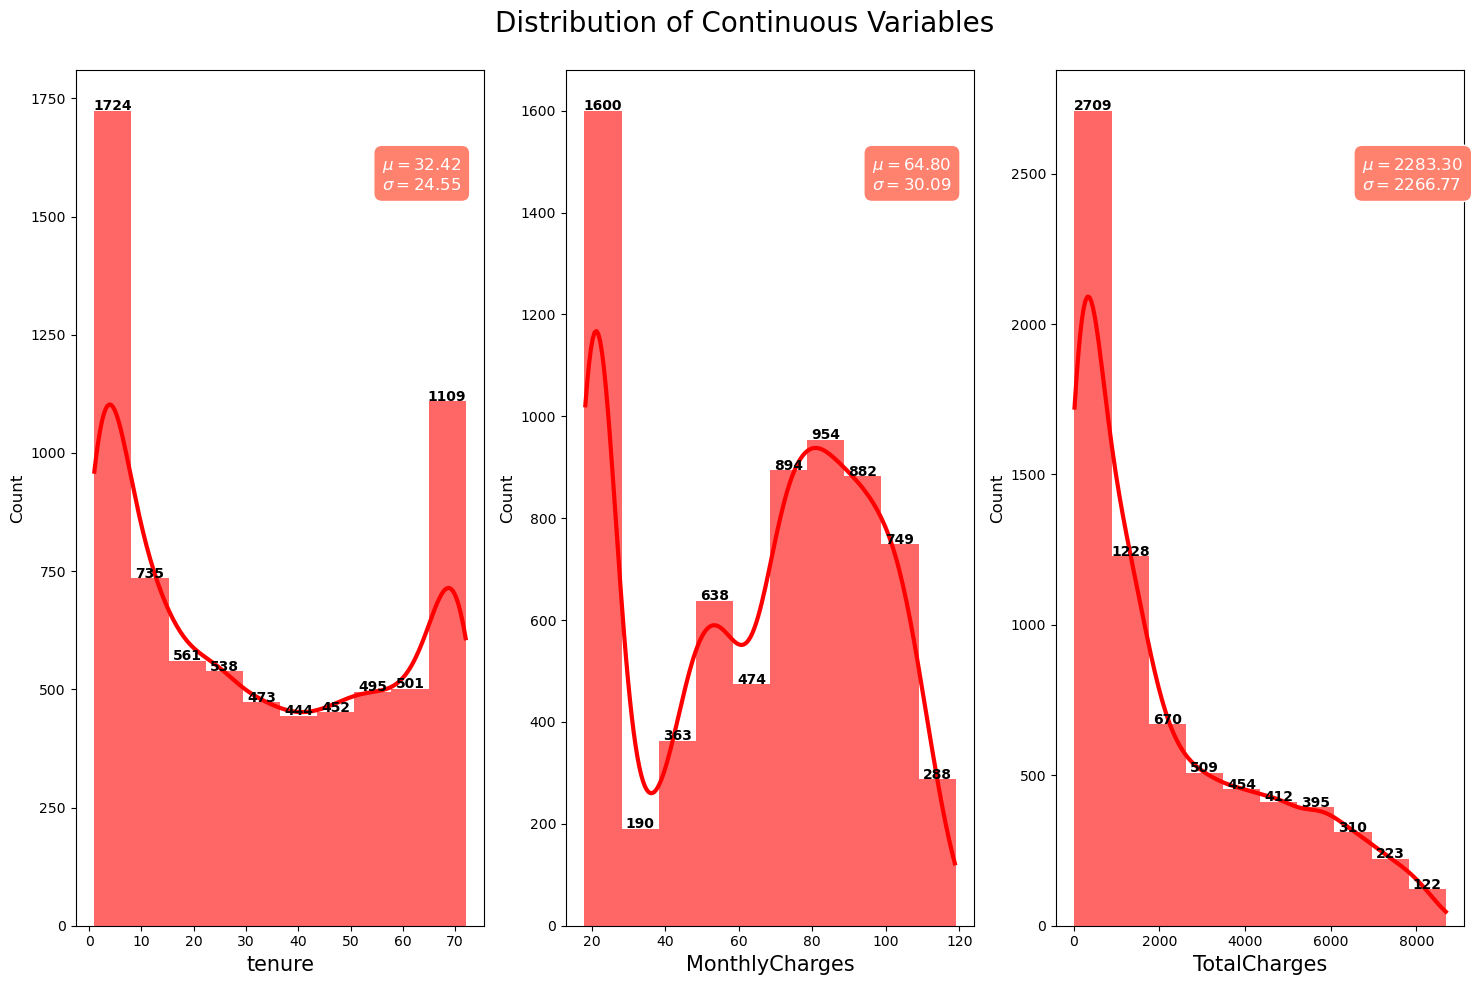

In [18]:
# Filter out continuous features for the univariate analysis
df_continuous = df[continuous_features]

# Set up the subplot
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))

# Loop to plot histograms for each continuous feature
for i, col in enumerate(df_continuous.columns):
    x = i // 3
    y = i % 3
    values, bin_edges = np.histogram(df_continuous[col], 
                                     range=(np.floor(df_continuous[col].min()), np.ceil(df_continuous[col].max())))
    
    graph = sns.histplot(
        data=df_continuous,
        x=col,
        bins=bin_edges,
        kde=True,
        ax=ax[i],
        edgecolor='none',
        color='red',
        alpha=0.6,
        line_kws={'lw': 3}
    )

    ax[i].set_xlabel(col, fontsize=15)
    ax[i].set_ylabel('Count', fontsize=12)
    
    for j, p in enumerate(graph.patches):
        ax[i].annotate('{}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                          ha='center', fontsize=10, fontweight="bold")
    
    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))
    ax[i].text(0.75, 0.9, textstr, transform=ax[i].transAxes, fontsize=12, verticalalignment='top',
                  color='white', bbox=dict(boxstyle='round', facecolor='#ff826e', edgecolor='white', pad=0.5))

plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [19]:
categorical_features = df.columns.difference(continuous_features)
df_categorical = df[categorical_features]
df_categorical

,Churn,Contract,Dependents,DeviceProtection,InternetService,MultipleLines,OnlineBackup,OnlineSecurity,PaperlessBilling,Partner,PaymentMethod,PhoneService,SeniorCitizen,StreamingMovies,StreamingTV,TechSupport,gender
0,No,Month-to-month,No,No,DSL,No phone service,Yes,No,Yes,Yes,Electronic check,No,No,No,No,No,Female
1,No,One year,No,Yes,DSL,No,No,Yes,No,No,Mailed check,Yes,No,No,No,No,Male
2,Yes,Month-to-month,No,No,DSL,No,Yes,Yes,Yes,No,Mailed check,Yes,No,No,No,No,Male
3,No,One year,No,Yes,DSL,No phone service,No,Yes,No,No,Bank transfer (automatic),No,No,No,No,Yes,Male
4,Yes,Month-to-month,No,No,Fiber optic,No,No,No,Yes,No,Electronic check,Yes,No,No,No,No,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,One year,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Mailed check,Yes,No,Yes,Yes,Yes,Male
7039,No,One year,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,Credit card (automatic),Yes,No,Yes,Yes,No,Female
7040,No,Month-to-month,Yes,No,DSL,No phone service,No,Yes,Yes,Yes,Electronic check,No,No,No,No,No,Female
7041,Yes,Month-to-month,No,No,Fiber optic,Yes,No,No,Yes,Yes,Mailed check,Yes,Yes,No,No,No,Male


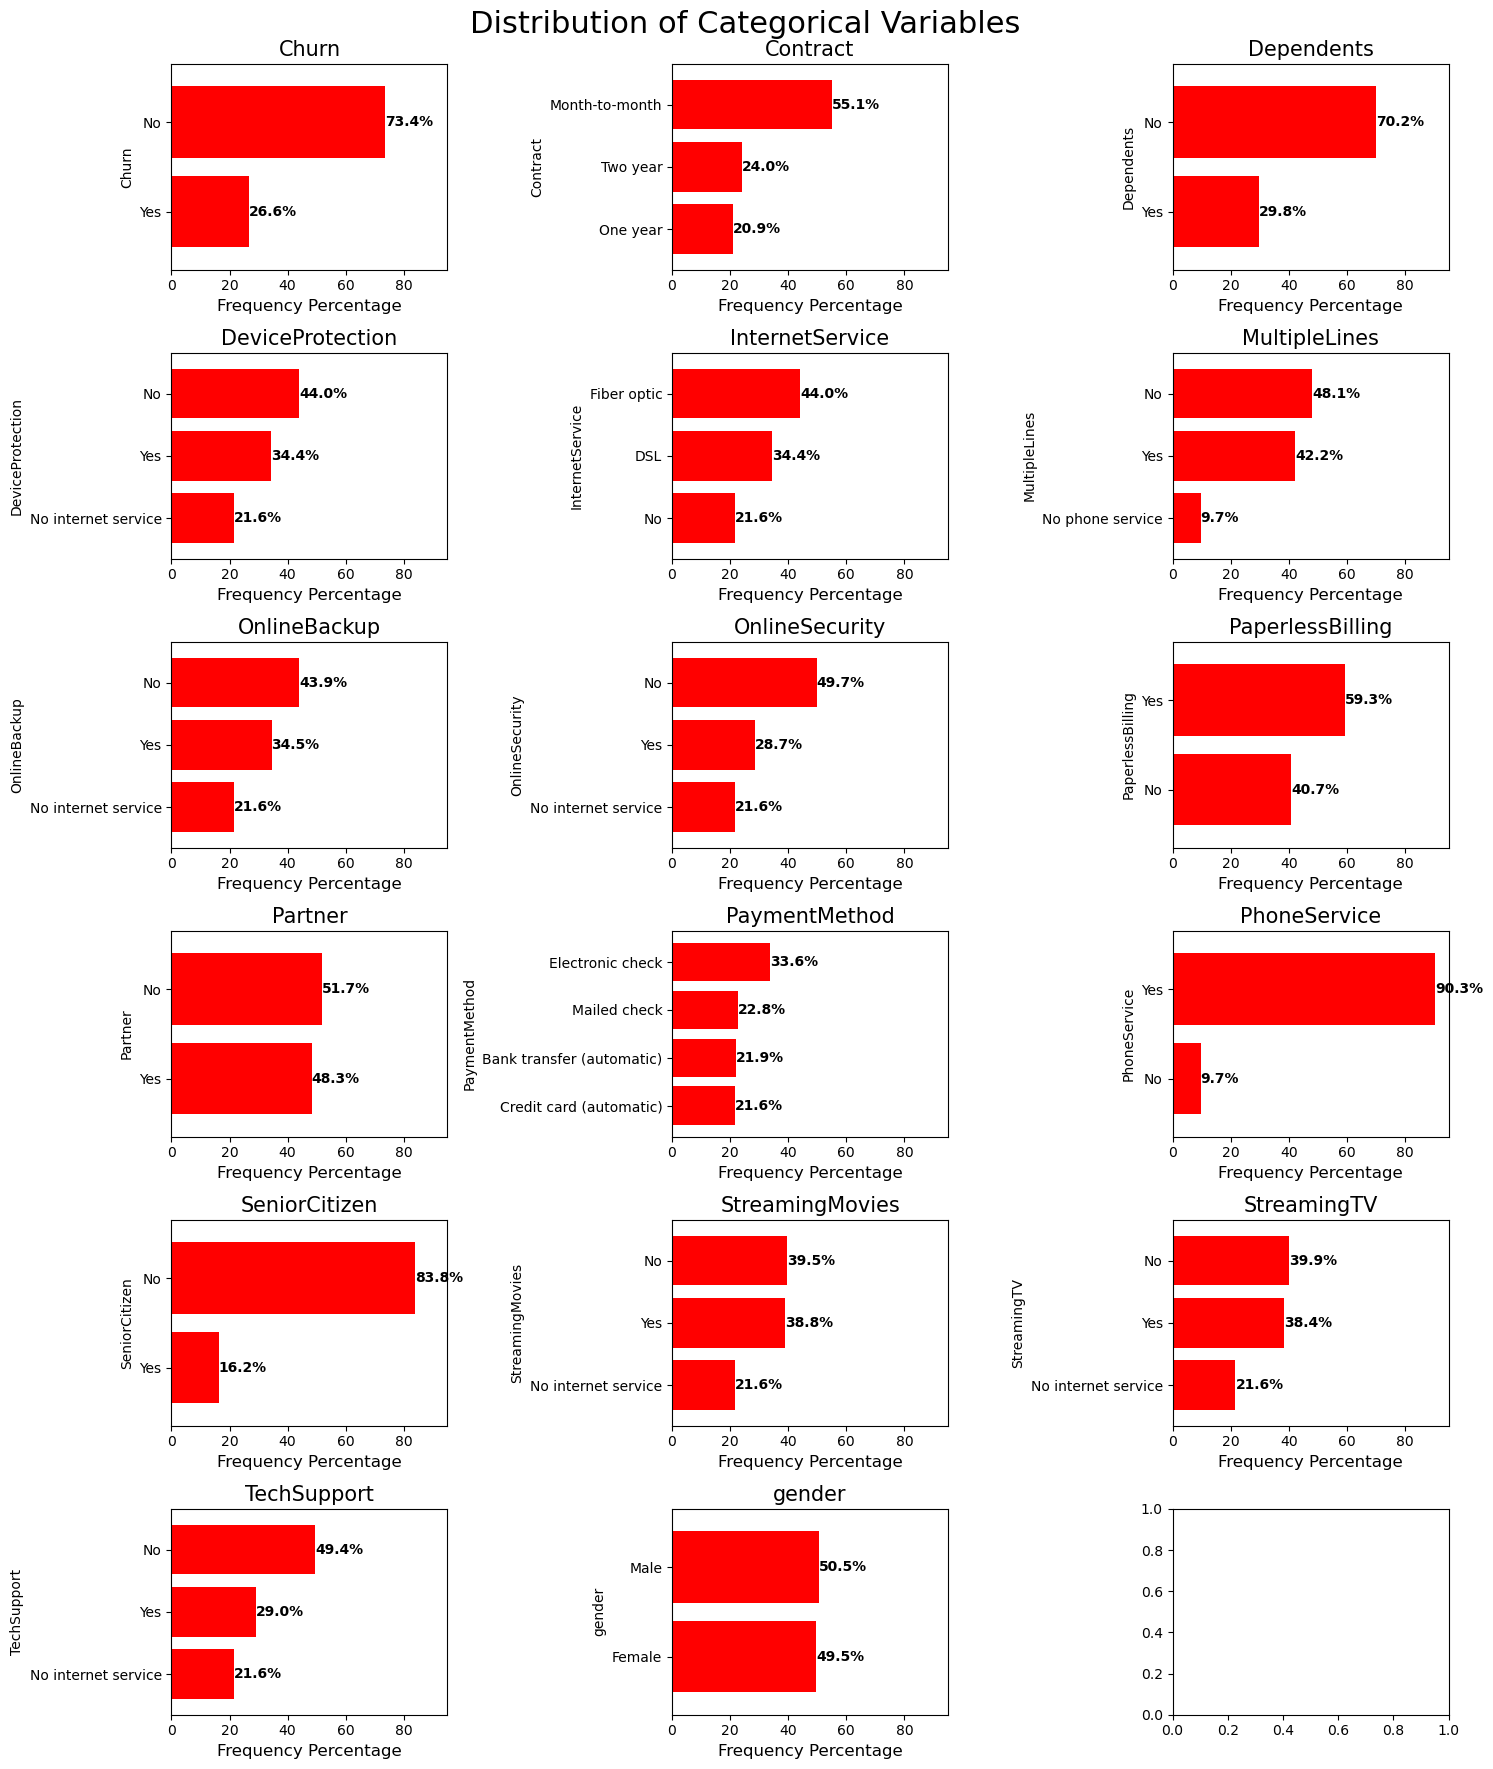

In [20]:
fig, ax = plt.subplots(nrows=6, ncols=3, figsize=(15, 18))

for i, col in enumerate(categorical_features):
    row = i // 3
    col_idx = i % 3

    value_counts = df[col].value_counts(normalize=True).mul(100).sort_values()

    value_counts.plot(
        kind='barh',
        ax=ax[row, col_idx],
        width=0.8,
        color='red'
    )

    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(
            value,
            index,
            str(round(value, 1)) + '%',
            fontsize=10,
            weight='bold',
            va='center'
        )

    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Frequency Percentage', fontsize=12)
    ax[row, col_idx].set_title(col, fontsize=15)

plt.suptitle('Distribution of Categorical Variables', fontsize=22)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [21]:
 df['Churn']=df['Churn'].map({"No":0, "Yes":1})

c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

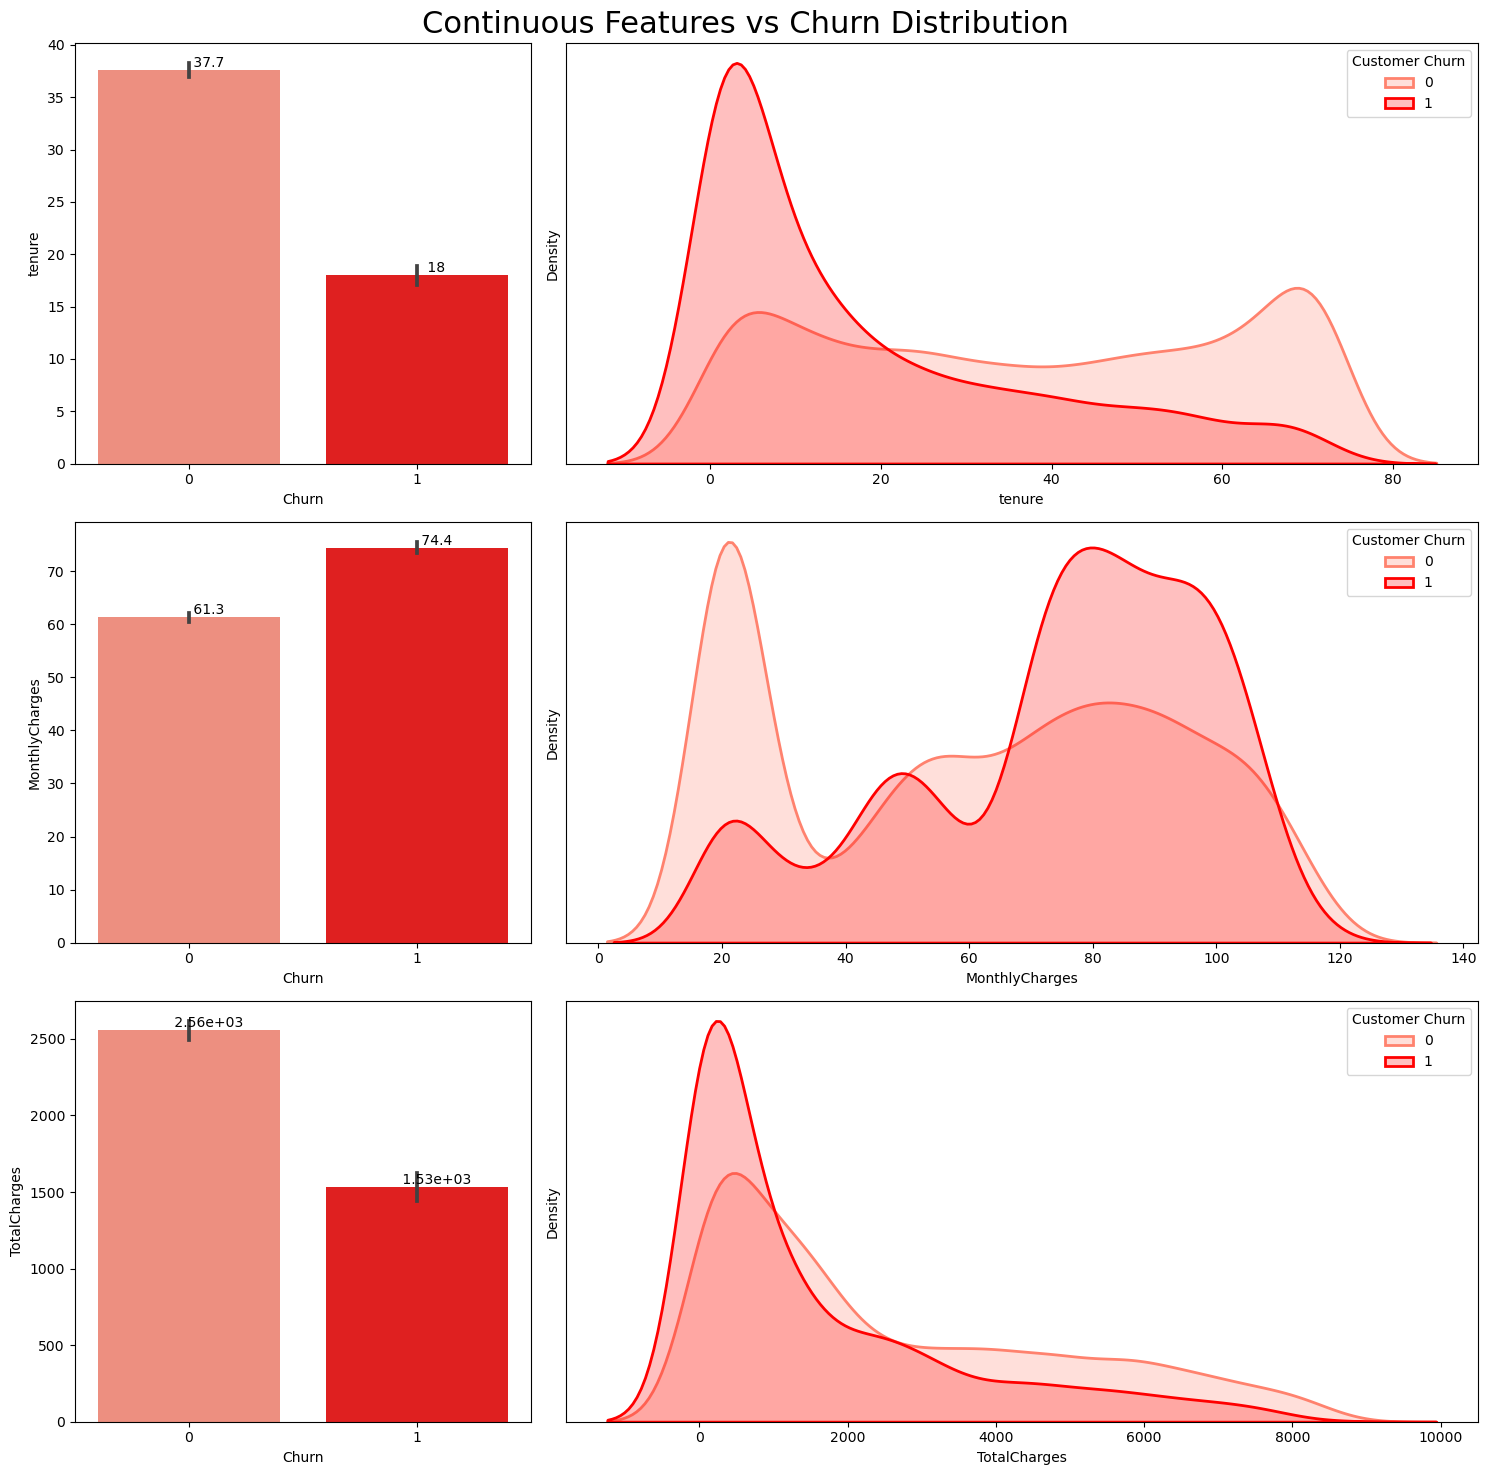

In [22]:
# Set color palette
sns.set_palette(['#ff826e', 'red'])

# Create the subplots
fig, ax = plt.subplots(len(continuous_features), 2, figsize=(15,15), gridspec_kw={'width_ratios': [1, 2]})

# Loop through each continuous feature to create barplots and kde plots
for i, col in enumerate(continuous_features):
    # Barplot showing the mean value of the feature for each target category
    graph = sns.barplot(data=df, x="Churn", y=col, ax=ax[i,0])
    
    # KDE plot showing the distribution of the feature for each target category
    sns.kdeplot(data=df[df["Churn"]==0], x=col, fill=True, linewidth=2, ax=ax[i,1], label='0')
    sns.kdeplot(data=df[df["Churn"]==1], x=col, fill=True, linewidth=2, ax=ax[i,1], label='1')
    ax[i,1].set_yticks([])
    ax[i,1].legend(title='Customer Churn', loc='upper right')
    
    # Add mean values to the barplot
    for cont in graph.containers:
        graph.bar_label(cont, fmt='         %.3g')
        
# Set the title for the entire figure
plt.suptitle('Continuous Features vs Churn Distribution', fontsize=22)
plt.tight_layout()                     
plt.show()


In [23]:
categorical_features = [feature for feature in categorical_features if feature != 'Churn']

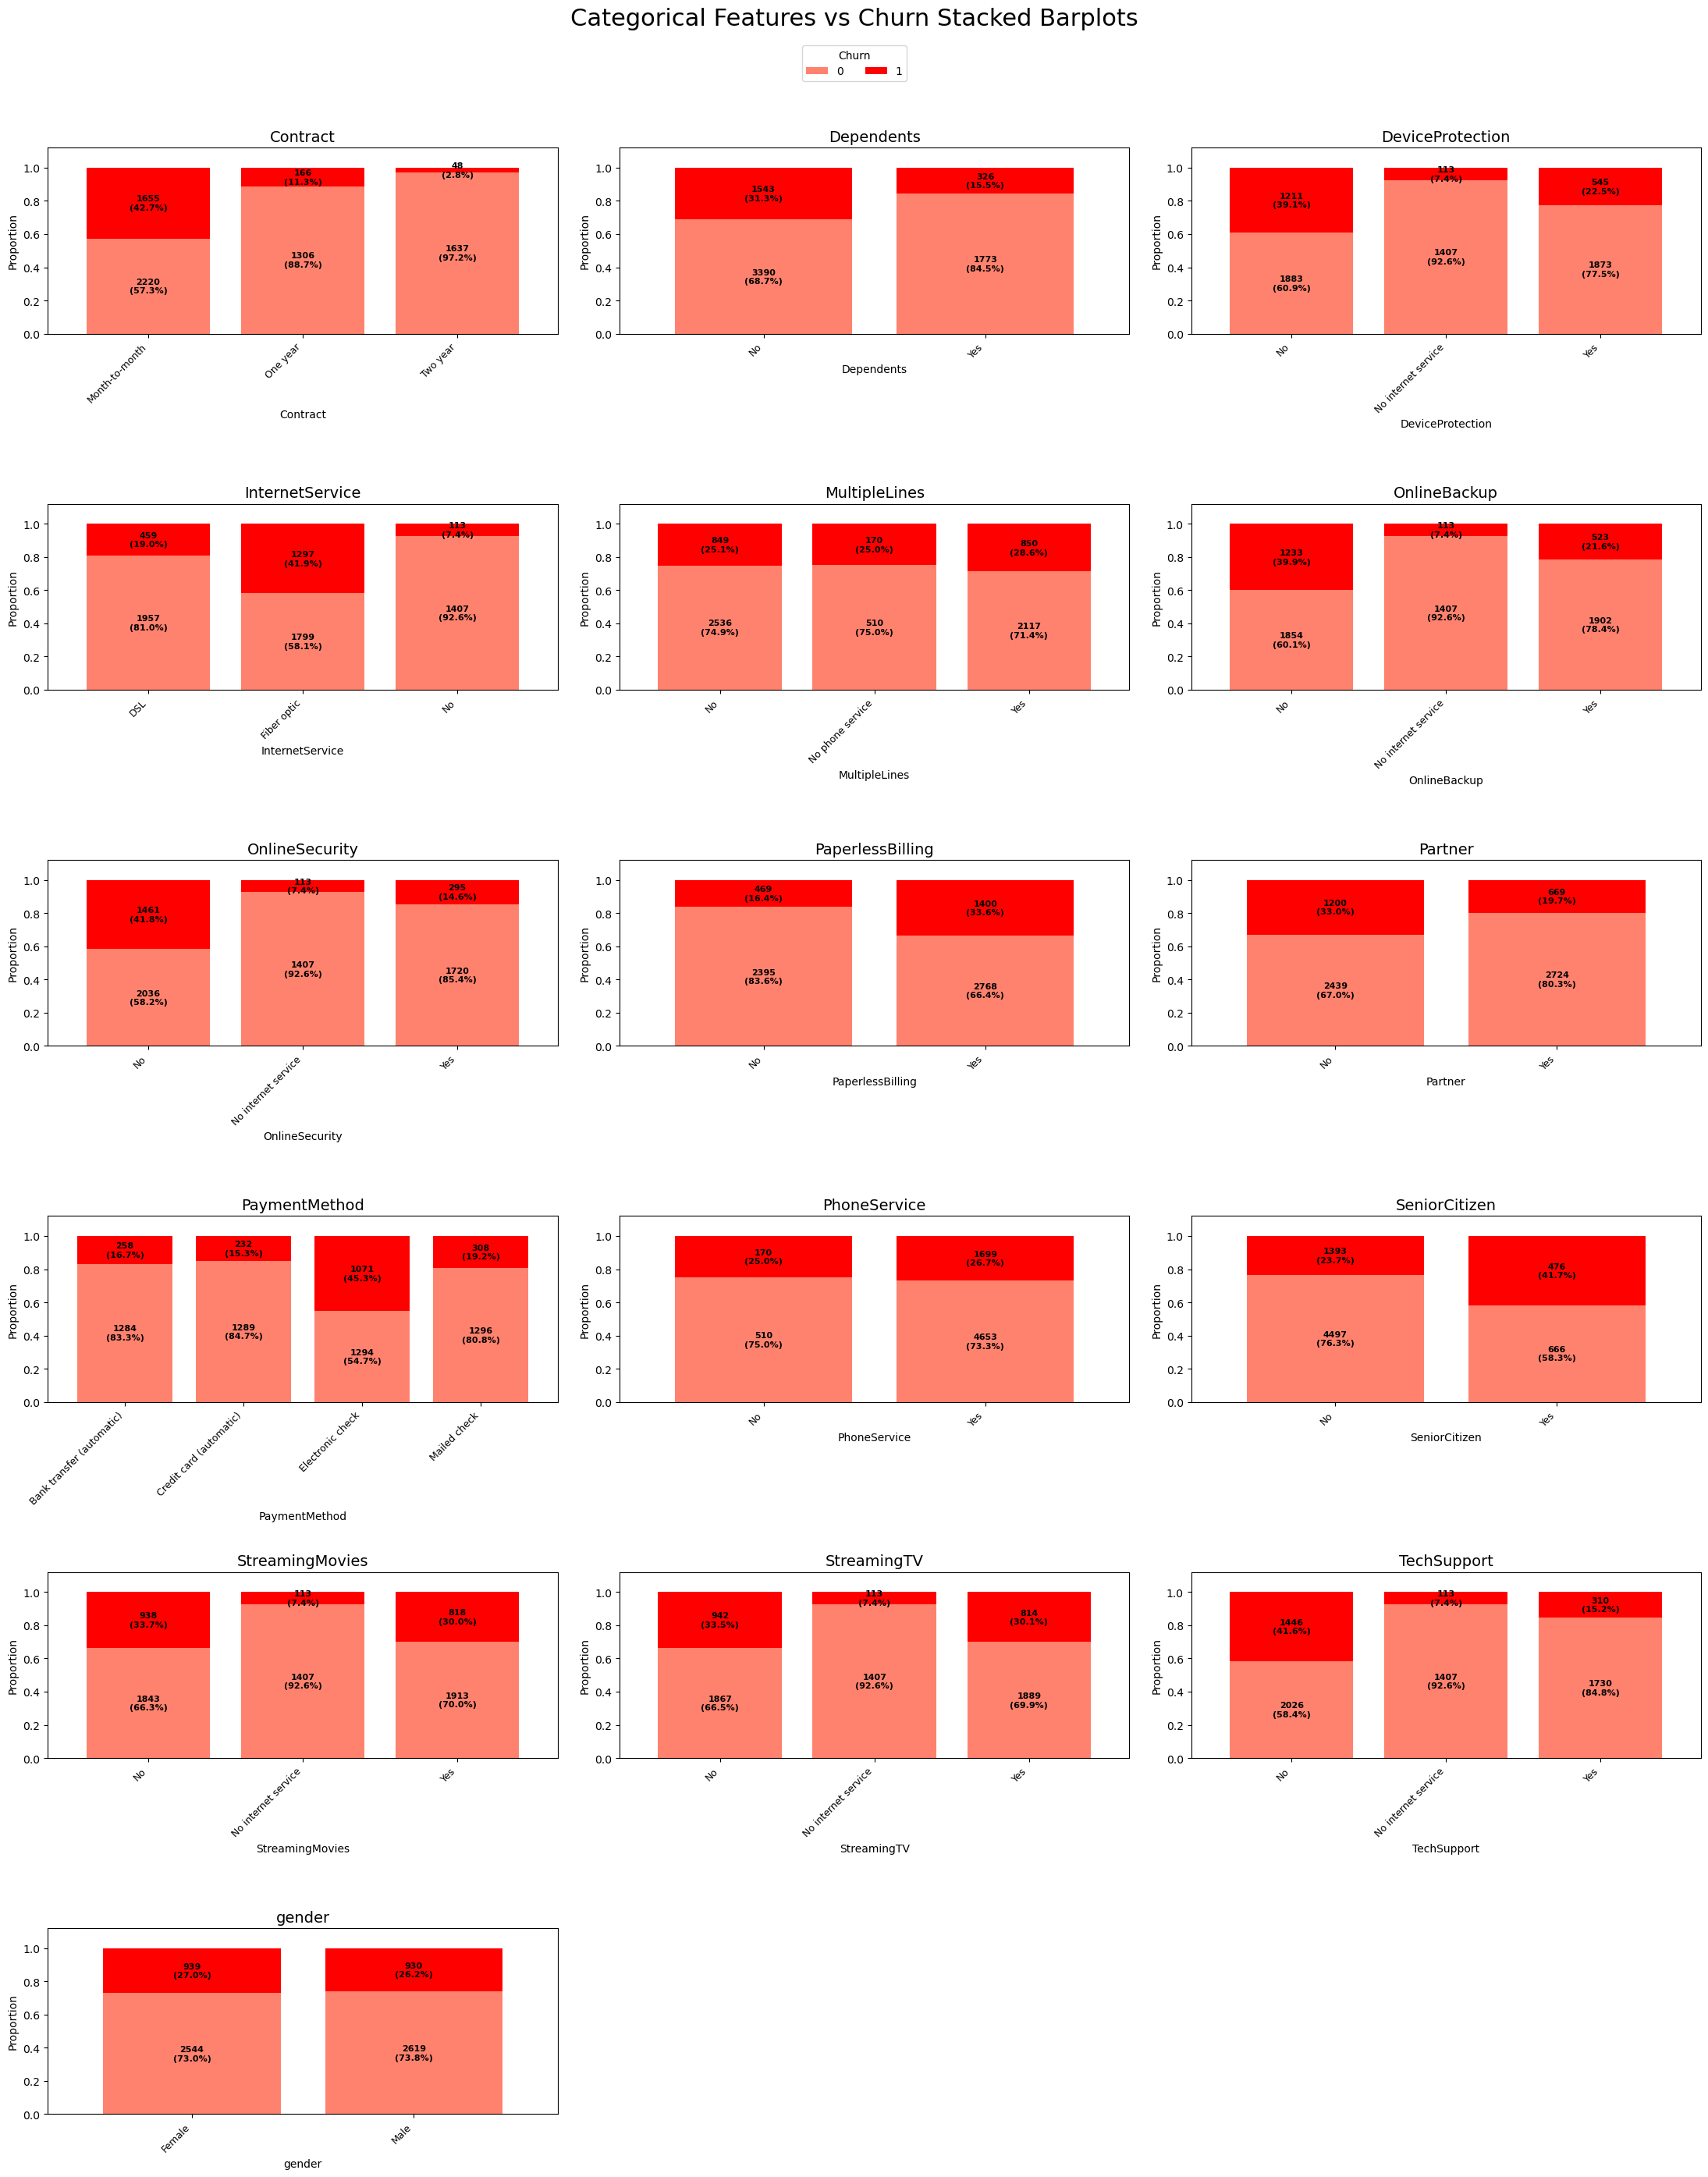

In [24]:
fig, ax = plt.subplots(
    nrows=6,
    ncols=3,
    figsize=(22, 28)
)

# Flatten axes for easier handling
ax = ax.flatten()

for i, col in enumerate(categorical_features):

    # Cross tabulation with counts
    cross_tab = pd.crosstab(
        index=df[col],
        columns=df['Churn']
    )

    # Proportions within each category
    cross_tab_prop = pd.crosstab(
        index=df[col],
        columns=df['Churn'],
        normalize='index'
    )

    # Plot stacked bar chart
    cross_tab_prop.plot(
        kind='bar',
        ax=ax[i],
        stacked=True,
        width=0.8,
        legend=False,
        ylabel='Proportion'
    )

    # Add counts and percentages
    for idx, val in enumerate(cross_tab.index.values):

        for proportion, count, y_location in zip(
            cross_tab_prop.loc[val],
            cross_tab.loc[val],
            cross_tab_prop.loc[val].cumsum()
        ):

            ax[i].text(
                x=idx,
                y=(y_location - proportion) + (proportion / 2),
                s=f'{count}\n({proportion * 100:.1f}%)',
                ha='center',
                va='center',
                color='black',
                fontsize=8,
                fontweight='bold'
            )

    # Plot formatting
    ax[i].set_title(col, fontsize=14)
    ax[i].set_ylim(0, 1.12)

    # Rotate x-axis labels
    ax[i].tick_params(
        axis='x',
        labelrotation=45,
        labelsize=9
    )

    # Align rotated labels
    for label in ax[i].get_xticklabels():
        label.set_horizontalalignment('right')


# Hide unused subplots
for j in range(len(categorical_features), len(ax)):
    ax[j].axis('off')


# Add one common legend for the entire figure
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Churn',
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.98)
)


plt.suptitle(
    'Categorical Features vs Churn Stacked Barplots',
    fontsize=22,
    y=0.995
)

# Add space between subplots
plt.tight_layout(
    rect=[0, 0, 1, 0.96],
    h_pad=3,
    w_pad=2
)

plt.show()

In [25]:

#
#Let's convert all the categorical variables into dummy variables
df = pd.get_dummies(df, dtype=int)
df.head()


,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,1,0,1,0,0,1,...,0,1,0,0,0,1,0,0,1,0
1,34,56.95,1889.50,0,0,1,1,0,1,0,...,0,0,1,0,1,0,0,0,0,1
2,2,53.85,108.15,1,0,1,1,0,1,0,...,0,1,0,0,0,1,0,0,0,1
3,45,42.30,1840.75,0,0,1,1,0,1,0,...,0,0,1,0,1,0,1,0,0,0
4,2,70.70,151.65,1,1,0,1,0,1,0,...,0,1,0,0,0,1,0,0,1,0


In [26]:
Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3 - Q1
outliers_count_specified = ((df[continuous_features] < (Q1 - 1.5 * IQR)) | (df[continuous_features] > (Q3 + 1.5 * IQR))).sum()

outliers_count_specified

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

In [27]:
x = df.drop('Churn', axis=1)
y = df['Churn'] 

In [28]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_train.shape,x_test.shape,y_train.shape,y_test.shape,

((5625, 46), (1407, 46), (5625,), (1407,))

In [30]:
for i in continuous_features:
    print(i,"\n",x_train[i].describe())

tenure 
 count    5625.000000
mean       32.562311
std        24.542421
min         1.000000
25%         9.000000
50%        29.000000
75%        56.000000
max        72.000000
Name: tenure, dtype: float64
MonthlyCharges 
 count    5625.000000
mean       64.999316
std        30.108642
min        18.400000
25%        35.800000
50%        70.600000
75%        90.050000
max       118.650000
Name: MonthlyCharges, dtype: float64
TotalCharges 
 count    5625.000000
mean     2301.839520
std      2275.586084
min        18.800000
25%       413.000000
50%      1410.250000
75%      3801.700000
max      8684.800000
Name: TotalCharges, dtype: float64


In [31]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

In [32]:
x_train['tenure'] = x_train['tenure'] + 0.001
x_test['tenure'] = x_test['tenure'] + 0.001

c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\priya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

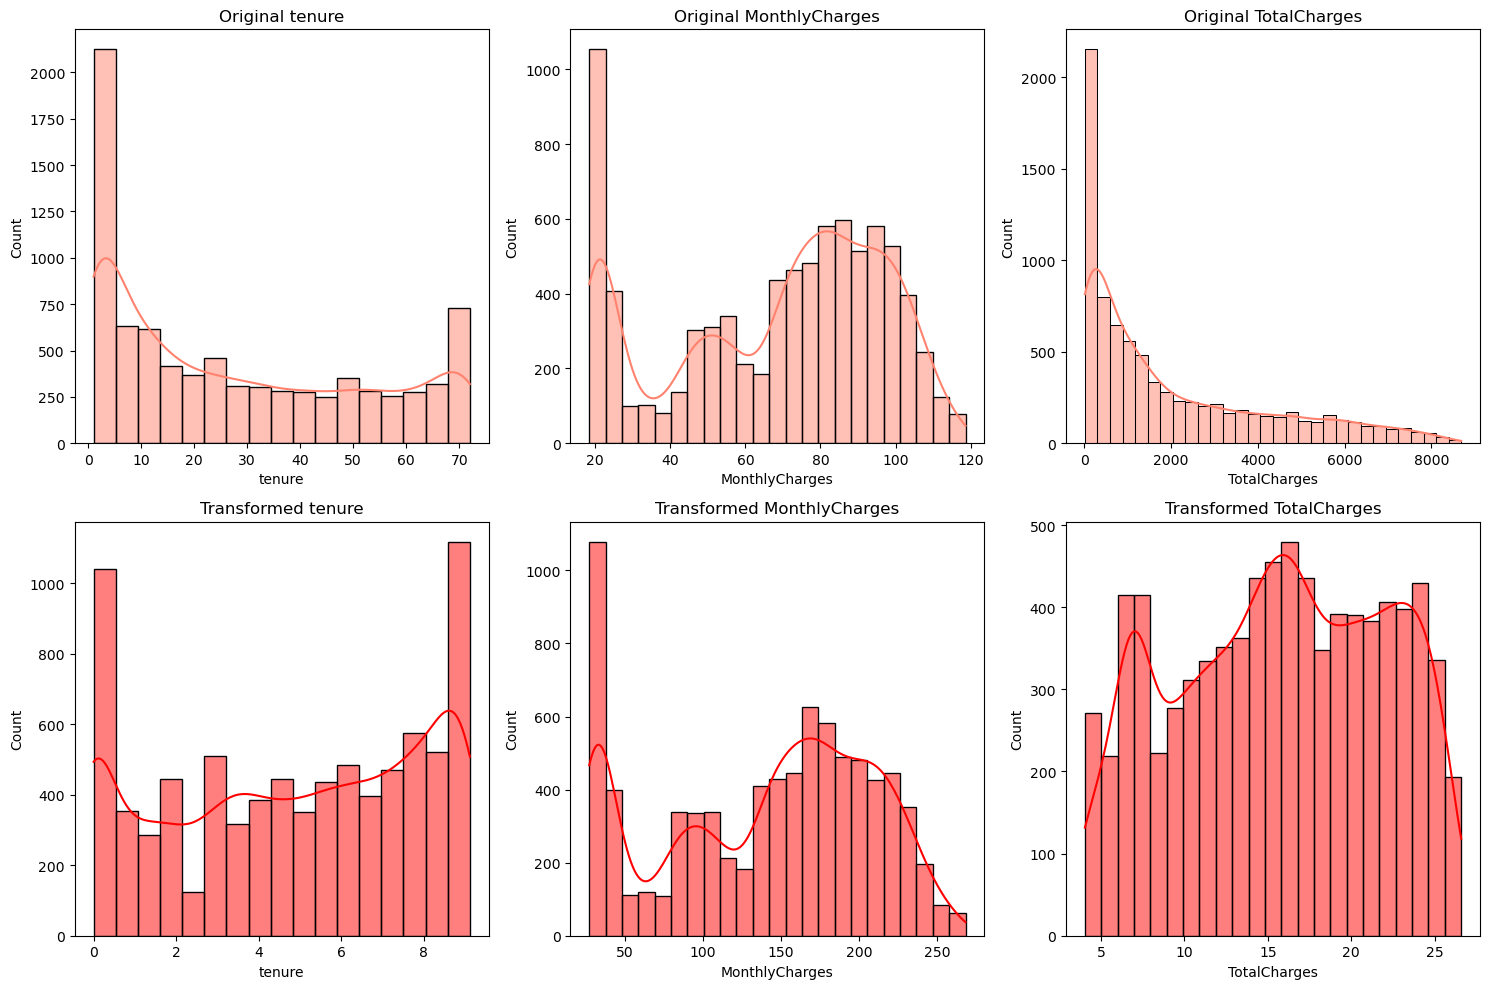

In [33]:
# Checking the distribution of the continuous features
fig, ax = plt.subplots(2, 3, figsize=(15,10))

# Original Distributions
for i, col in enumerate(continuous_features):
    sns.histplot(x_train[col], kde=True, ax=ax[0,i]).set_title(f'Original {col}')
    

# Applying Box-Cox Transformation
# Dictionary to store lambda values for each feature
lambdas = {}

for i, col in enumerate(continuous_features):
    # Only apply box-cox for positive values
    if x_train[col].min() > 0:
        x_train[col], lambdas[col] = boxcox(x_train[col])
        # Applying the same lambda to test data
        x_test[col] = boxcox(x_test[col], lmbda=lambdas[col]) 
        sns.histplot(x_train[col], kde=True, ax=ax[1,i], color='red').set_title(f'Transformed {col}')
    else:
        sns.histplot(x_train[col], kde=True, ax=ax[1,i], color='green').set_title(f'{col} (Not Transformed)')

fig.tight_layout()
plt.show()

In [34]:
y_test.value_counts()

Churn
0    1033
1     374
Name: count, dtype: int64

In [35]:
dt_base = DecisionTreeClassifier(random_state=0)

In [36]:
def tune_clf_hyperparameters(clf, param_grid, x_train, y_train, scoring='recall', n_splits=3):
    # Create the cross-validation object using StratifiedKFold to ensure 
    #the class distribution is the same across all the folds
    
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    # Create the GridSearchCV object
    clf_grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)

    # Fit the GridSearchCV object to the training data
    clf_grid.fit(x_train, y_train)

    # Get the best hyperparameters
    best_hyperparameters = clf_grid.best_params_
    
    # Return best_estimator_ attribute which gives us the best model that has been fitted to the training data
    return clf_grid.best_estimator_, best_hyperparameters

In [37]:
# Hyperparameter grid for DT
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2,3],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2]
}

In [38]:
x_train.head()

,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,8.723381,203.438538,24.363074,0,1,1,0,0,1,0,...,0,0,0,1,1,0,0,1,0,0
1,5.721513,62.048624,15.382987,0,1,1,0,1,0,1,...,0,1,0,0,1,0,0,0,1,0
2,8.895040,192.109349,24.576800,1,0,1,0,0,1,1,...,0,0,0,1,1,0,0,1,0,0
3,1.315715,176.927959,10.094634,0,1,1,0,1,0,1,...,1,1,0,0,1,0,0,0,1,0
4,7.702676,72.635162,18.549656,1,0,1,0,0,1,1,...,0,1,0,0,1,0,1,0,0,0


In [39]:
# Call the function for hyperparameter tuning
best_dt, best_dt_hyperparams = tune_clf_hyperparameters(dt_base, param_grid_dt, x_train, y_train)
print('DT Optimal Hyperparameters: \n', best_dt_hyperparams)

DT Optimal Hyperparameters: 
 {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [40]:
print(classification_report(y_train, best_dt.predict(x_train)))

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      4130
           1       0.73      0.91      0.81      4130

    accuracy                           0.79      8260
   macro avg       0.81      0.79      0.79      8260
weighted avg       0.81      0.79      0.79      8260



In [41]:
print(classification_report(y_test, best_dt.predict(x_test)))

              precision    recall  f1-score   support

           0       0.90      0.63      0.74      1033
           1       0.44      0.81      0.57       374

    accuracy                           0.68      1407
   macro avg       0.67      0.72      0.66      1407
weighted avg       0.78      0.68      0.70      1407



In [42]:
def evaluate_model(model, x_test, y_test, model_name):

    # Make predictions
    y_pred = model.predict(x_test)
    
    # Get classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Extracting metrics
    metrics = {
        "precision_0": report["0"]["precision"],
        "precision_1": report["1"]["precision"],
        "recall_0": report["0"]["recall"],
        "recall_1": report["1"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],
        "macro_avg_precision": report["macro avg"]["precision"],
        "macro_avg_recall": report["macro avg"]["recall"],
        "macro_avg_f1": report["macro avg"]["f1-score"],
        "accuracy": accuracy_score(y_test, y_pred)
    }
    
    # Convert dictionary to dataframe
    df = pd.DataFrame(metrics, index=[model_name]).round(2)
    
    return df

In [43]:
dt_evaluation = evaluate_model(best_dt, x_test, y_test, 'DT')
dt_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
DT,0.9,0.44,0.63,0.81,0.74,0.57,0.67,0.72,0.66,0.68


In [44]:
rf_base = RandomForestClassifier(random_state=0)

In [45]:
param_grid_rf = {
    'n_estimators': [10, 30, 50, 70, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [True, False]
}

In [46]:
best_rf, best_rf_hyperparams = tune_clf_hyperparameters(rf_base, param_grid_rf, x_train, y_train)

print('RF Optimal Hyperparameters: \n', best_rf_hyperparams)

RF Optimal Hyperparameters: 
 {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 30}


In [47]:
print(classification_report(y_train, best_rf.predict(x_train)))

              precision    recall  f1-score   support

           0       0.85      0.75      0.80      4130
           1       0.78      0.87      0.82      4130

    accuracy                           0.81      8260
   macro avg       0.81      0.81      0.81      8260
weighted avg       0.81      0.81      0.81      8260



In [48]:
print(classification_report(y_test, best_rf.predict(x_test)))

              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1033
           1       0.49      0.75      0.59       374

    accuracy                           0.72      1407
   macro avg       0.69      0.73      0.69      1407
weighted avg       0.78      0.72      0.74      1407



In [49]:
rf_evaluation = evaluate_model(best_rf, x_test, y_test, 'RF')
rf_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
RF,0.89,0.49,0.71,0.75,0.79,0.59,0.69,0.73,0.69,0.72


In [50]:
# Define the base KNN model and set up the pipeline with scaling
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [51]:
# Hyperparameter grid for KNN
knn_param_grid = {
    'knn__n_neighbors': list(range(1, 12)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # 1: Manhattan distance, 2: Euclidean distance
}

In [52]:
# Hyperparameter tuning for KNN
best_knn, best_knn_hyperparams = tune_clf_hyperparameters(knn_pipeline, knn_param_grid, x_train, y_train)
print('KNN Optimal Hyperparameters: \n', best_knn_hyperparams)

KNN Optimal Hyperparameters: 
 {'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}


In [53]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_knn.predict(x_train)))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87      4130
           1       0.86      0.89      0.87      4130

    accuracy                           0.87      8260
   macro avg       0.87      0.87      0.87      8260
weighted avg       0.87      0.87      0.87      8260



In [54]:
print(classification_report(y_test, best_knn.predict(x_test)))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1033
           1       0.51      0.61      0.56       374

    accuracy                           0.74      1407
   macro avg       0.68      0.70      0.69      1407
weighted avg       0.76      0.74      0.75      1407



In [55]:
knn_evaluation = evaluate_model(best_knn, x_test, y_test, 'KNN')
knn_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
KNN,0.85,0.51,0.79,0.61,0.82,0.56,0.68,0.7,0.69,0.74


In [56]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True)) 
])

In [57]:
param_grid_svm = {
    'svm__C': [0.1],
    'svm__kernel': ['linear'],
    'svm__gamma': ['auto'],  
    'svm__degree': [3]
}

In [58]:
# Call the function for hyperparameter tuning
best_svm, best_svm_hyperparams = tune_clf_hyperparameters(svm_pipeline, param_grid_svm, x_train, y_train)
print('SVM Optimal Hyperparameters: \n', best_svm_hyperparams)

SVM Optimal Hyperparameters: 
 {'svm__C': 0.1, 'svm__degree': 3, 'svm__gamma': 'auto', 'svm__kernel': 'linear'}


In [59]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_svm.predict(x_train)))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      4130
           1       0.90      0.82      0.86      4130

    accuracy                           0.86      8260
   macro avg       0.87      0.86      0.86      8260
weighted avg       0.87      0.86      0.86      8260



In [60]:
# Evaluate the optimized model on the test data
print(classification_report(y_test, best_svm.predict(x_test)))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [61]:
svm_evaluation = evaluate_model(best_svm, x_test, y_test, 'SVM')
svm_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
SVM,0.83,0.63,0.89,0.51,0.86,0.56,0.73,0.7,0.71,0.79


In [62]:
from xgboost import XGBClassifier
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier()) 
])

In [63]:
param_grid_xgb = {
    'xgb__n_estimators': [100],
    'xgb__max_depth': [5],
    'xgb__learning_rate': [0.1],
    'xgb__subsample': [0.8],
    'xgb__colsample_bytree': [0.8,],
    'xgb__min_child_weight': [1,],
    'xgb__gamma': [0.1, 0.5]
}

In [64]:
best_xgb, best_xgb_hyperparams = tune_clf_hyperparameters(xgb_pipeline, param_grid_xgb, x_train, y_train)
print('XGB Optimal Hyperparameters: \n', best_xgb_hyperparams)

XGB Optimal Hyperparameters: 
 {'xgb__colsample_bytree': 0.8, 'xgb__gamma': 0.1, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}


In [65]:
print(classification_report(y_train, best_xgb.predict(x_train)))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      4130
           1       0.91      0.88      0.90      4130

    accuracy                           0.90      8260
   macro avg       0.90      0.90      0.90      8260
weighted avg       0.90      0.90      0.90      8260



In [66]:
print(classification_report(y_test, best_xgb.predict(x_test)))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1033
           1       0.60      0.58      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [67]:
xgb_evaluation = evaluate_model(best_xgb, x_test, y_test, 'XGB')
xgb_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
XGB,0.85,0.6,0.86,0.58,0.86,0.59,0.73,0.72,0.72,0.79


In [68]:
# Concatenate the dataframes
all_evaluations = [dt_evaluation, rf_evaluation, knn_evaluation, svm_evaluation, xgb_evaluation]
results = pd.concat(all_evaluations)

# Sort by 'recall_1'
results = results.sort_values(by='recall_1', ascending=False).round(2)
results

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
DT,0.90,0.44,0.63,0.81,0.74,0.57,0.67,0.72,0.66,0.68
RF,0.89,0.49,0.71,0.75,0.79,0.59,0.69,0.73,0.69,0.72
KNN,0.85,0.51,0.79,0.61,0.82,0.56,0.68,0.70,0.69,0.74
XGB,0.85,0.60,0.86,0.58,0.86,0.59,0.73,0.72,0.72,0.79
SVM,0.83,0.63,0.89,0.51,0.86,0.56,0.73,0.70,0.71,0.79


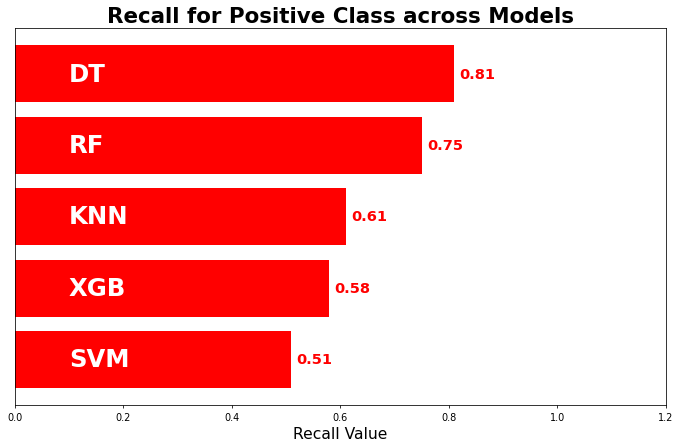

In [69]:
# Sort values based on 'recall_1'
results.sort_values(by='recall_1', ascending=True, inplace=True)
recall_1_scores = results['recall_1']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7), dpi=70)
ax.barh(results.index, recall_1_scores, color='red')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(recall_1_scores, results.index)):
    ax.text(value + 0.01, i, f"{value:.2f}", ha='left', va='center', fontweight='bold', color='red', fontsize=15)
    ax.text(0.1, i, name, ha='left', va='center', fontweight='bold', color='white', fontsize=25)

# Remove yticks
ax.set_yticks([])

# Set x-axis limit
ax.set_xlim([0, 1.2])

# Add title and xlabel
plt.title("Recall for Positive Class across Models", fontweight='bold', fontsize=22)
plt.xlabel('Recall Value', fontsize=16)
plt.show()

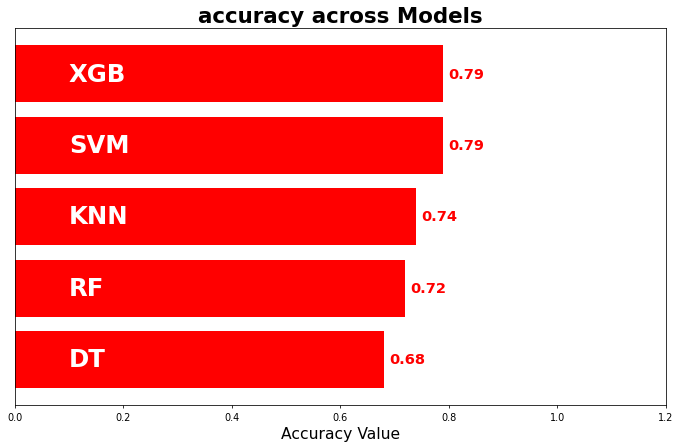

In [70]:
results.sort_values(by='accuracy', ascending=True, inplace=True)
accuracy_scores = results['accuracy']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7), dpi=70)
ax.barh(results.index, accuracy_scores, color='red')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(accuracy_scores, results.index)):
    ax.text(value + 0.01, i, f"{value:.2f}", ha='left', va='center', fontweight='bold', color='red', fontsize=15)
    ax.text(0.1, i, name, ha='left', va='center', fontweight='bold', color='white', fontsize=25)

# Remove yticks
ax.set_yticks([])

# Set x-axis limit
ax.set_xlim([0, 1.2])

# Add title and xlabel
plt.title("accuracy across Models", fontweight='bold', fontsize=22)
plt.xlabel('Accuracy Value', fontsize=16)
plt.show()

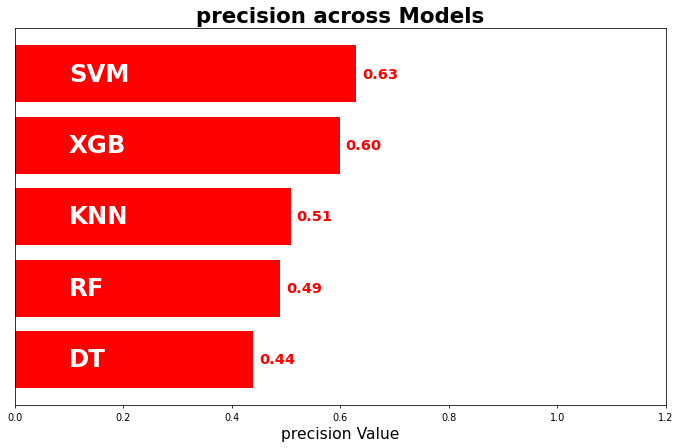

In [71]:
results.sort_values(by='precision_1', ascending=True, inplace=True)
precision_scores = results['precision_1']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7), dpi=70)
ax.barh(results.index, precision_scores, color='red')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(precision_scores, results.index)):
    ax.text(value + 0.01, i, f"{value:.2f}", ha='left', va='center', fontweight='bold', color='red', fontsize=15)
    ax.text(0.1, i, name, ha='left', va='center', fontweight='bold', color='white', fontsize=25)

# Remove yticks
ax.set_yticks([])

# Set x-axis limit
ax.set_xlim([0, 1.2])

# Add title and xlabel
plt.title("precision across Models", fontweight='bold', fontsize=22)
plt.xlabel('precision Value', fontsize=16)
plt.show()

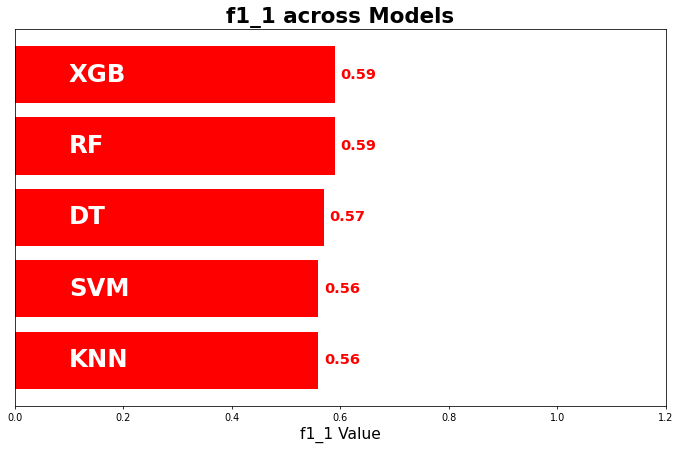

In [72]:
results.sort_values(by='f1_1', ascending=True, inplace=True)
precision_scores = results['f1_1']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7), dpi=70)
ax.barh(results.index, precision_scores, color='red')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(precision_scores, results.index)):
    ax.text(value + 0.01, i, f"{value:.2f}", ha='left', va='center', fontweight='bold', color='red', fontsize=15)
    ax.text(0.1, i, name, ha='left', va='center', fontweight='bold', color='white', fontsize=25)

# Remove yticks
ax.set_yticks([])

# Set x-axis limit
ax.set_xlim([0, 1.2])

# Add title and xlabel
plt.title("f1_1 across Models", fontweight='bold', fontsize=22)
plt.xlabel('f1_1 Value', fontsize=16)
plt.show()

In [73]:
print(results[['precision_1', 'recall_1', 'f1_1', 'accuracy']])

     precision_1  recall_1  f1_1  accuracy
KNN         0.51      0.61  0.56      0.74
SVM         0.63      0.51  0.56      0.79
DT          0.44      0.81  0.57      0.68
RF          0.49      0.75  0.59      0.72
XGB         0.60      0.58  0.59      0.79


In [74]:
import joblib

joblib.dump(best_xgb, "xgb_model.pkl")
joblib.dump(lambdas, "boxcox_lambdas.pkl")
joblib.dump(list(x_train.columns), "feature_columns.pkl")

['feature_columns.pkl']